In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import easyocr
from collections import Counter
from pathlib import Path
import os
from collections import defaultdict
from video_scoreboard_reader import process_video_file
import shutil

In [ ]:
# CONFIG
REPO_ROOT = Path(os.getcwd()).parent  


ROBOT_MODEL_PATH = REPO_ROOT / "yolov8_model" / "best_tuned_yolov8.pt"
NUMBER_MODEL_PATH = REPO_ROOT / "number_reading" / "best_number.pt"

ROBOT_CLASS_ID = 1
BLUE_NUMBER_CLASS_ID = 0
RED_NUMBER_CLASS_ID = 1

FRAME_SKIP = 15

CUSTOM_TRACKER_PATH = REPO_ROOT / "trackers" / "botsort_custom.yaml"


In [4]:
# LOAD MODELS
robot_model = YOLO(ROBOT_MODEL_PATH)
number_model = YOLO(NUMBER_MODEL_PATH)

reader = easyocr.Reader(['en'], gpu=True)

In [ ]:
# BOTSORT
print("Loading model...")
model = YOLO(ROBOT_MODEL_PATH)

def run_botsort(model_path, video_path, tracker_path, save_video=False, output_dir=None, stride=1):

    model = YOLO(model_path)

    print("Running BotSort tracking...")

    results = model.track(
        source=video_path,
        tracker=tracker_path,
        stream=True,
        persist=True,
        conf=0.35,
        device=0,
        vid_stride=stride,
        verbose=False
    )

    tracking_results = []
    video_writer = None

    for frame_i, result in enumerate(results):

        if result.boxes is None or result.boxes.xyxy is None:
            continue

        boxes = result.boxes.xyxy.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)
        ids = result.boxes.id

        if ids is None:
            continue

        ids = ids.cpu().numpy().astype(int)

        robot_indices = [i for i, c in enumerate(classes) if c == ROBOT_CLASS_ID]

        frame = result.plot()

        for i in robot_indices:

            x1, y1, x2, y2 = boxes[i]
            track_id = ids[i]

            # STORE RESULT
            tracking_results.append({
                "frame": frame_i * stride,
                "track_id": int(track_id),
                "box": [float(x1), float(y1), float(x2), float(y2)],
                "crop": frame[int(y1):int(y2), int(x1):int(x2)].copy()
            })

            # DRAW
            cv2.putText(
                frame,
                f"ID {track_id}",
                (int(x1), int(y1) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

        if save_video:
            if video_writer is None:
                h, w = frame.shape[:2]
                output_path = output_dir / "botsort_with_ids.mp4"

                video_writer = cv2.VideoWriter(
                    str(output_path),
                    cv2.VideoWriter_fourcc(*"mp4v"),
                    30,
                    (w, h)
                )

            video_writer.write(frame)

    if video_writer:
        video_writer.release()

    print("Tracking complete.")
    return tracking_results

Loading model...


In [ ]:
# IMAGE PROCESSING FUNCTIONS
def estimate_angle_from_crop(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return 0.0

    cnt = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(cnt)
    angle = rect[-1]

    if angle < -45:
        angle += 90

    return angle


def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )


def preprocess_crop(crop, threshold):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    angle = estimate_angle_from_crop(crop)
    rotated = rotate_image(thresh, angle)

    return rotated

def preprocess_variants(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    variants = []

    # 1. SIMPLE
    for t in [150, 165, 180, 195, 210]:
        _, th = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)
        variants.append(th)

    # 2. ADAPTIVE
    adaptive = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )
    variants.append(adaptive)

    # 3. OTSU
    _, otsu = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    variants.append(otsu)

    # 4. HISTOGRAM
    eq = cv2.equalizeHist(gray)
    _, th_eq = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants.append(th_eq)

    return variants

In [7]:
def find_closest_frame(target_frame, available_frames):
    return min(available_frames, key=lambda f: abs(f - target_frame))

In [ ]:
import math

def assign_coral_to_robot(coral_df, tracking_lookup, final_labels):

    assigned_rows = []

    available_frames = sorted(tracking_lookup.keys())

    for _, row in coral_df.iterrows():

        coral_frame = row["frame"]
        coral_x = row["x"]
        coral_y = row["y"]

        if coral_x is None or coral_y is None:
            assigned_rows.append({**row, "robot_id": None})
            continue

        # 1. CLOSEST FRAME
        closest_frame = find_closest_frame(coral_frame, available_frames)

        tracks = tracking_lookup.get(closest_frame, [])

        best_dist = float("inf")
        best_robot = None
        best_track_id = None

        # 2. CLOSEST ROBOT
        for t in tracks:
            x1, y1, x2, y2 = t["box"]

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            dx = cx - coral_x
            dy = cy - coral_y

            dist = math.sqrt((dx**2) * 2.0 + (dy**2) * 0.5)

            if dist < best_dist:
                best_dist = dist
                best_track_id = t["track_id"]

        # 3. MAP TO NUMBER
        if best_track_id in final_labels:
            best_robot = final_labels[best_track_id]
        else:
            best_robot = None

        assigned_rows.append({
            **row,
            "closest_frame": closest_frame,
            "track_id": best_track_id,
            "robot_id": best_robot,
            "distance": best_dist
        })

    return pd.DataFrame(assigned_rows)

In [ ]:
# OCR
def read_number_from_image(img):
    variants = preprocess_variants(img)
    guesses = []

    angle = estimate_angle_from_crop(img)
    for processed in variants:
        rotated = rotate_image(processed, angle)

        results = reader.readtext(
            rotated,
            allowlist="0123456789",
            detail=1,
            paragraph=False
        )

        results = [r for r in results if r[2] > 0.5]

        if results:
            guesses.append(results[0][1])

    if not guesses:
        return None

    c = Counter(guesses)
    max_count = max(c.values())

    tied = [num for num, count in c.items() if count == max_count]

    return max(tied, key=lambda x: len(str(x)))

In [10]:
# MATCHING SYSTEM
def levenshtein(a, b):
    a, b = str(a), str(b)
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]

    for i in range(len(a)+1):
        dp[i][0] = i
    for j in range(len(b)+1):
        dp[0][j] = j

    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )

    return dp[-1][-1]


def similarity(a, b):
    if not a or not b:
        return 0
    dist = levenshtein(a, b)
    return 1 - dist / max(len(str(a)), len(str(b)))


def alignment_score(a, b):
    a, b = str(a), str(b)
    best = 0

    for shift in range(-len(b), len(a)+1):
        matches = 0
        for i in range(len(a)):
            j = i - shift
            if 0 <= j < len(b) and a[i] == b[j]:
                matches += 1
        best = max(best, matches)

    return best / max(len(a), len(b))


def combined_score(a, b, w1=0.7, w2=0.3):
    return w1 * similarity(a, b) + w2 * alignment_score(a, b)


def match_number_single(detected, nums):
    if detected is None:
        return None

    best_score = 0.5
    match = None

    for n in nums:
        current = combined_score(detected, n)
        if current > best_score:
            best_score = current
            match = n

    return match

In [ ]:
def apply_elimination(final_labels, track_candidates, all_ids, tracks):
    assigned_ids = set(final_labels.values())
    remaining_ids = set(all_ids) - assigned_ids

    unlabeled_tracks = [t for t in tracks if t not in final_labels]

    # PERFECT ELIMINATION
    if len(unlabeled_tracks) == len(remaining_ids):
        for t, rid in zip(unlabeled_tracks, remaining_ids):
            final_labels[t] = rid

    # CANDIDATE FILTERING
    else:
        for t in unlabeled_tracks:
            candidates = set(track_candidates.get(t, []))
            candidates -= assigned_ids

            if len(candidates) == 1:
                final_labels[t] = candidates.pop()

    return final_labels

In [ ]:
# NUMBER READING
def read_numbers(tracking_results, blue_team_numbers=[], red_team_numbers=[], stride=1):

    results = []
    current_frame = None
    frame_data = []

    for entry in tracking_results:

        frame_idx = entry["frame"]
        robot_crop = entry["crop"]

        if frame_idx % stride != 0:
            continue

        if current_frame is None:
            current_frame = frame_idx

        if frame_idx != current_frame:
            print(f"Frame {current_frame}: {frame_data}")
            results.append({
                "frame": current_frame,
                "detections": frame_data
            })
            frame_data = []
            current_frame = frame_idx

        if robot_crop is None or robot_crop.size == 0:
            continue

        number_results = number_model(robot_crop, verbose=False)[0]

        for nbox in number_results.boxes:
            cls_id = int(nbox.cls[0])
            if cls_id == RED_NUMBER_CLASS_ID:
                team_list = red_team_numbers
            elif cls_id == BLUE_NUMBER_CLASS_ID:
                team_list = blue_team_numbers
            else:
                continue

            if nbox.conf[0] < 0.6:
                continue

            nx1, ny1, nx2, ny2 = map(int, nbox.xyxy[0])


            pad = 5
            h2, w2 = robot_crop.shape[:2]
            nx1 = max(0, nx1 - pad)
            ny1 = max(0, ny1 - pad)
            nx2 = min(w2, nx2 + pad)
            ny2 = min(h2, ny2 + pad)

            if (nx2 - nx1) < 30 or (ny2 - ny1) < 15:
                continue

            number_crop = robot_crop[ny1:ny2, nx1:nx2]

            if number_crop.size == 0:
                continue

            detected = read_number_from_image(number_crop)
            matched = match_number_single(detected, team_list)

            frame_data.append({
                "detected": detected,
                "matched": matched,
                "track_id": entry["track_id"],
                "box": entry["box"],
                "alliance_hint": "blue" if cls_id == BLUE_NUMBER_CLASS_ID else "red"
            })

    if frame_data:
        print(f"Frame {current_frame}: {frame_data}")
        results.append({
            "frame": current_frame,
            "detections": frame_data
        })

    return results

In [ ]:
def run_full_pipeline(
    video_path,
    robot_model_path,
    number_model_path,
    tracker_path,
    blue_ids,
    red_ids,
    output_path,
    tracking_stride=1,
    ocr_stride=1
):
    from scipy.optimize import linear_sum_assignment
    import numpy as np

    print("Running BotSort...")
    botsort_results = run_botsort(
        robot_model_path,
        video_path,
        tracker_path,
        stride=tracking_stride
    )

    print("Reading numbers...")
    output = read_numbers(
        botsort_results,
        blue_ids,
        red_ids,
        stride=ocr_stride
    )

    # 1: ALLIANCE DETECTION
    track_alliance_votes = defaultdict(lambda: {"blue": 0, "red": 0})

    for frame in output:
        for det in frame["detections"]:
            tid = det["track_id"]
            match = det["matched"]

            hint = det.get("alliance_hint")
            if hint == "blue":
                track_alliance_votes[tid]["blue"] += 2
            elif hint == "red":
                track_alliance_votes[tid]["red"] += 2

            if match in blue_ids:
                track_alliance_votes[tid]["blue"] += 1
            elif match in red_ids:
                track_alliance_votes[tid]["red"] += 1

    track_alliance = {}

    for tid, votes in track_alliance_votes.items():
        if votes["blue"] > votes["red"]:
            track_alliance[tid] = "blue"
        elif votes["red"] > votes["blue"]:
            track_alliance[tid] = "red"
        else:
            track_alliance[tid] = None

    # 2: TRACK MEMORY
    track_memory = defaultdict(list)

    for frame in output:
        for det in frame["detections"]:
            tid = det["track_id"]
            match = det["matched"]

            if match is None:
                continue

            alliance = track_alliance.get(tid)

            if alliance == "blue" and match in blue_ids:
                track_memory[tid].append(match)
            elif alliance == "red" and match in red_ids:
                track_memory[tid].append(match)

    # 3: GLOBAL UNIQUE MATCHING
    all_tracks = list(track_memory.keys())
    all_ids = list(blue_ids) + list(red_ids)

    if len(all_tracks) == 0:
        final_labels = {}
    else:
        cost_matrix = np.full((len(all_tracks), len(all_ids)), fill_value=1e6)

        for i, tid in enumerate(all_tracks):
            nums = track_memory[tid]
            if not nums:
                continue

            scores = defaultdict(float)

            # RECENCY WEIGHTING
            for j, num in enumerate(nums):
                weight = 0.9 ** (len(nums) - j)
                scores[num] += weight

            total_weight = sum(scores.values())
            if total_weight == 0:
                continue

            alliance = track_alliance.get(tid)

            for j, rid in enumerate(all_ids):

                if alliance == "blue" and rid not in blue_ids:
                    continue
                if alliance == "red" and rid not in red_ids:
                    continue

                if rid in scores:
                    confidence = scores[rid] / total_weight

                    if confidence < 0.4:
                        continue

                    cost_matrix[i, j] = -confidence  # maximize

        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        final_labels = {}
        for r, c in zip(row_ind, col_ind):
            if cost_matrix[r, c] < 0:
                final_labels[all_tracks[r]] = all_ids[c]

    print("Final track labels:", final_labels)

    # 4: BUILD LOOKUP
    tracking_lookup = defaultdict(list)

    for entry in botsort_results:
        tracking_lookup[entry["frame"]].append(entry)

    # 5: DRAW VIDEO
    print("Drawing Video...")

    cap = cv2.VideoCapture(video_path)
    video_writer = None

    frame_idx = 0
    last_drawn = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        if frame_idx in tracking_lookup:
            draw_frame = frame.copy()

            for entry in tracking_lookup[frame_idx]:
                tid = entry["track_id"]
                x1, y1, x2, y2 = map(int, entry["box"])

                alliance = track_alliance.get(tid)

                if alliance == "blue":
                    color = (255, 0, 0)
                elif alliance == "red":
                    color = (0, 0, 255)
                else:
                    color = (200, 200, 200)

                cv2.rectangle(draw_frame, (x1, y1), (x2, y2), color, 2)

                if tid in final_labels:
                    text = str(final_labels[tid])
                else:
                    text = f"ID {tid}"

                cv2.putText(
                    draw_frame,
                    text,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    color,
                    2
                )

            last_drawn = draw_frame

        if last_drawn is None:
            continue

        if video_writer is None:
            h, w = last_drawn.shape[:2]
            video_writer = cv2.VideoWriter(
                str(output_path),
                cv2.VideoWriter_fourcc(*"mp4v"),
                30,
                (w, h)
            )

        video_writer.write(last_drawn)

    cap.release()

    if video_writer:
        video_writer.release()

    print("Pipeline complete. Video saved to:", output_path)

    return {
        "tracking": botsort_results,
        "ocr_output": output,
        "final_labels": final_labels
    }

In [ ]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO
import os
import pandas as pd

# CONFIG
VIDEO_FOLDER = 'videos'

SLOT_CAPACITIES = [3, 1, 2, 2, 1, 3]
NUM_SLOTS = len(SLOT_CAPACITIES)
NUM_REEFS = 2

HISTORY_LEN = 5
MIN_CONF = 0.5
TOP_ZONE_RATIO = 0.20

CONFIRM_FRAMES = 3

EMPTY = 0
FILLING = 1
FILLED = 2

model = YOLO('models/best_coral.pt')

# HELPERS
def get_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2)/2, (y1 + y2)/2)

def assign_to_reef_and_slot(cx, cy, reefs):
    for r_idx, r in enumerate(reefs):
        rx1, ry1, rx2, ry2 = r
        rw, rh = rx2 - rx1, ry2 - ry1

        if (rx1 < cx < rx2) and (ry1 < cy < ry1 + rh*TOP_ZONE_RATIO):
            rel_x = cx - rx1
            slot_width = rw / NUM_SLOTS
            slot_margin = slot_width * 0.1
            slot = int((rel_x - slot_margin)/slot_width)
            slot = max(0, min(slot, NUM_SLOTS-1))
            return r_idx, slot
    return None, None

In [15]:
VIDEO_PATH = "videos/video.mp4"

In [ ]:
# MAIN
video_file = os.path.basename(VIDEO_PATH)

print(f"\nProcessing: {video_file}")

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"\nProcessing: {video_file}")

cap = cv2.VideoCapture(os.path.join(VIDEO_FOLDER, video_file))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cutoff_frame = total_frames - int(49*fps)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
crop_h = int(height*(2/5))
start_y = height - crop_h

# STATE
reef_grids = [[0]*NUM_SLOTS for _ in range(NUM_REEFS)]
history = [[deque(maxlen=HISTORY_LEN) for _ in range(NUM_SLOTS)] for _ in range(NUM_REEFS)]

states = [[EMPTY]*NUM_SLOTS for _ in range(NUM_REEFS)]
timers = [[0]*NUM_SLOTS for _ in range(NUM_REEFS)]

total_points = 0
frame_idx = 0

events = []

# LOOP
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= cutoff_frame:
        break

    cropped = frame[start_y:height, 0:width]
    results = model(cropped, conf=MIN_CONF, verbose=False)

    boxes = results[0].boxes.xyxy.cpu().numpy() if results[0].boxes else []
    clss  = results[0].boxes.cls.cpu().numpy().astype(int) if results[0].boxes else []
    confs = results[0].boxes.conf.cpu().numpy() if results[0].boxes else []

    reefs = [boxes[i] for i, c in enumerate(clss) if model.names[c]=='reef']
    reefs.sort(key=lambda x: x[0])

    if len(reefs) < NUM_REEFS:
        frame_idx += 1
        continue

    reefs = reefs[:NUM_REEFS]

    # COUNT RAW
    raw_counts = [[0]*NUM_SLOTS for _ in range(NUM_REEFS)]
    raw_positions = [[[] for _ in range(NUM_SLOTS)] for _ in range(NUM_REEFS)]

    for i, c in enumerate(clss):
        if model.names[c] != 'coral' or confs[i] < MIN_CONF:
            continue

        cx, cy = get_center(boxes[i])
        r_idx, slot = assign_to_reef_and_slot(cx, cy, reefs)

        if (
            r_idx is not None and
            slot is not None and
            0 <= r_idx < NUM_REEFS and
            0 <= slot < NUM_SLOTS
        ):
            raw_counts[r_idx][slot] += 1
            raw_positions[r_idx][slot].append((cx, cy))

    # SMOOTH
    smoothed = [[0]*NUM_SLOTS for _ in range(NUM_REEFS)]
    for r in range(NUM_REEFS):
        for s in range(NUM_SLOTS):
            history[r][s].append(raw_counts[r][s])
            smoothed[r][s] = int(round(np.median(history[r][s])))

    # MARKOV STATE UPDATE
    DECAY = 1
    GROWTH = 1
    THRESHOLD = 4

    for r in range(NUM_REEFS):
        for s in range(NUM_SLOTS):

            curr = smoothed[r][s]
            placed = reef_grids[r][s]

            if placed >= SLOT_CAPACITIES[s]:
                continue

            stable = history[r][s].count(curr) >= 3

            if curr >= placed + 1 and stable:
                timers[r][s] += GROWTH
            else:
                timers[r][s] -= DECAY

            timers[r][s] = max(-THRESHOLD, timers[r][s])

            # EVENT DETECTION
            if timers[r][s] >= THRESHOLD:
                reef_grids[r][s] += 1
                total_points += 4

                # ESTIMATE POSITION
                if raw_positions[r][s]:
                    avg_x = int(np.mean([p[0] for p in raw_positions[r][s]]))
                    avg_y = int(np.mean([p[1] for p in raw_positions[r][s]]))
                else:
                    avg_x, avg_y = None, None

                # LOG EVENT
                events.append({
                    "frame": frame_idx,
                    "reef": r,
                    "slot": s,
                    "new_count": reef_grids[r][s],
                    "x": avg_x,
                    "y": avg_y
                })

                timers[r][s] = -THRESHOLD

    frame_idx += 1

cap.release()

# RESULTS
print(f"Total points: {total_points}")
for r in range(NUM_REEFS):
    print(f"Reef {r}: {reef_grids[r]}")

coral_df = pd.DataFrame(events)

print("\nEvent DataFrame:")
print(coral_df)

# SAVE CSV
output_csv = f"{video_file}_coral_events.csv"
coral_df.to_csv(output_csv, index=False)
print(f"Saved to {output_csv}")


Processing: video.mp4

Processing: video.mp4
Total points: 84
Reef 0: [2, 1, 2, 2, 1, 3]
Reef 1: [3, 1, 2, 1, 1, 2]

Event DataFrame:
    frame  reef  slot  new_count     x   y
0     321     0     0          1   360  79
1     322     1     5          1  1534  88
2     325     0     5          1   605  75
3     331     1     0          1  1311  85
4     505     0     5          2   599  71
5     546     1     4          1  1507  68
6     556     1     1          1  1335  66
7     640     0     4          1   558  60
8     654     0     2          1   449  52
9     931     1     0          2  1304  74
10   1136     0     3          1   495  54
11   1383     0     0          2   349  78
12   1454     1     2          1  1397  59
13   1495     0     3          2   501  69
14   1774     1     3          1  1453  90
15   1795     0     2          2   443  71
16   2101     0     1          1   387  59
17   2324     1     2          2  1392  75
18   3831     1     5          2  1535  87
19   

In [17]:
scoreboard_df = process_video_file(VIDEO_PATH)

In [18]:
from collections import Counter

counts = Counter(team for teams in scoreboard_df["blue_team_numbers"] for team in teams)
majority = counts.most_common(3)
BLUE_IDS = [majority[0][0], majority[1][0], majority[2][0]]
counts = Counter(team for teams in scoreboard_df["red_team_numbers"] for team in teams)
majority = counts.most_common(3)
RED_IDS = [majority[0][0], majority[1][0], majority[2][0]]

In [20]:
# RUN
video_files = sorted(Path("cropped_videos").glob("*.mp4"), key=os.path.getmtime)
VIDEO_PATH = str(video_files[-1])

output_dir = REPO_ROOT / "tracking_output"
output_dir.mkdir(exist_ok=True)

botsort_results = run_full_pipeline( 
    VIDEO_PATH,
    ROBOT_MODEL_PATH,
    NUMBER_MODEL_PATH,
    CUSTOM_TRACKER_PATH,
    BLUE_IDS,
    RED_IDS,
    output_path=output_dir / "final_output.mp4",
    tracking_stride=3,
    ocr_stride=15
)


Running BotSort...
Running BotSort tracking...
Tracking complete.
Reading numbers...
Frame 105: []
Frame 120: []
Frame 135: []
Frame 150: []
Frame 165: []
Frame 180: []
Frame 195: []
Frame 210: []
Frame 225: []
Frame 270: []
Frame 285: [{'detected': '233', 'matched': 2338, 'track_id': 6, 'box': [179.7533721923828, 21.764394760131836, 372.2793884277344, 408.40765380859375], 'alliance_hint': 'blue'}]
Frame 300: [{'detected': '23', 'matched': None, 'track_id': 6, 'box': [182.56484985351562, 0.0, 370.29217529296875, 405.03631591796875], 'alliance_hint': 'blue'}, {'detected': '186', 'matched': None, 'track_id': 8, 'box': [1486.3692626953125, 2.1734089851379395, 1687.157958984375, 430.9126892089844], 'alliance_hint': 'blue'}]
Frame 315: [{'detected': '23', 'matched': None, 'track_id': 6, 'box': [180.97459411621094, 5.840038776397705, 367.3856201171875, 407.62738037109375], 'alliance_hint': 'blue'}]
Frame 330: [{'detected': '8778', 'matched': None, 'track_id': 6, 'box': [170.54763793945312, 8

In [21]:
from collections import defaultdict

tracking_lookup = defaultdict(list)

for entry in botsort_results["tracking"]:
    tracking_lookup[entry["frame"]].append(entry)


assigned_df = assign_coral_to_robot(
    coral_df,
    tracking_lookup,
    botsort_results["final_labels"]
)

print(assigned_df)

    frame  reef  slot  new_count     x   y  closest_frame  track_id  robot_id  \
0     321     0     0          1   360  79            321         6    2338.0   
1     322     1     5          1  1534  88            321         8       NaN   
2     325     0     5          1   605  75            324        11    4020.0   
3     331     1     0          1  1311  85            330         5    4028.0   
4     505     0     5          2   599  71            504        13       NaN   
5     546     1     4          1  1507  68            546         8       NaN   
6     556     1     1          1  1335  66            555         5    4028.0   
7     640     0     4          1   558  60            639        13       NaN   
8     654     0     2          1   449  52            654         9       NaN   
9     931     1     0          2  1304  74            930        18       NaN   
10   1136     0     3          1   495  54           1137        36       NaN   
11   1383     0     0       

In [22]:
unknown_events = assigned_df[assigned_df["robot_id"].isna()].copy()

In [ ]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import cv2

def review_all_events(
    video_path,
    assigned_df,
    tracking_lookup,
    final_labels,
    blue_ids,
    red_ids
):
    cap = cv2.VideoCapture(video_path)

    all_robot_options = list(blue_ids) + list(red_ids)
    user_labels = []

    for idx, row in assigned_df.iterrows():

        frame_num = int(row["closest_frame"])

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            continue

        draw = frame.copy()

        tracks = tracking_lookup.get(frame_num, [])

        # -----------------------------
        # FIND CLOSEST ROBOT (SCORER)
        # -----------------------------
        best_tid = None
        best_dist = float("inf")

        if row["x"] is not None and row["y"] is not None:
            coral_x, coral_y = row["x"], row["y"]

            for t in tracks:
                x1, y1, x2, y2 = t["box"]
                cx = (x1 + x2) / 2
                cy = (y1 + y2) / 2

                # Weighted distance (favor X)
                dx = abs(cx - coral_x)
                dy = abs(cy - coral_y)
                dist = dx * 2.5 + dy * 0.5

                if dist < best_dist:
                    best_dist = dist
                    best_tid = t["track_id"]

        # DRAW ROBOTS
        for t in tracks:
            x1, y1, x2, y2 = map(int, t["box"])
            tid = t["track_id"]

            if tid in final_labels:
                label = final_labels[tid]
            else:
                label = f"ID {tid}"

            # COLOR PRIORITY
            if tid == best_tid:
                color = (0, 255, 0)
            elif tid in final_labels:
                color = (0, 165, 255)
            else:
                color = (0, 0, 255)

            cv2.rectangle(draw, (x1, y1), (x2, y2), color, 2)
            cv2.putText(draw, str(label), (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # DRAW CORAL
        if row["x"] is not None and row["y"] is not None:
            cx, cy = int(row["x"]), int(row["y"])

            if pd.isna(row["robot_id"]):
                coral_color = (255, 0, 0)
            else:
                coral_color = (0, 255, 0)

            cv2.circle(draw, (cx, cy), 8, coral_color, -1)

        draw_rgb = cv2.cvtColor(draw, cv2.COLOR_BGR2RGB)

        # SHOW FRAME
        plt.figure(figsize=(8, 6))
        plt.imshow(draw_rgb)
        plt.title(
            f"Frame {frame_num} | Current: {row['robot_id']} | Closest: {best_tid}"
        )
        plt.axis("off")
        plt.show()
        plt.close()

        # USER INPUT (ONLY IF UNKNOWN)
        if pd.isna(row["robot_id"]):

            print("\nSelect robot:")
            for i, rid in enumerate(all_robot_options):
                print(f"{i+1}: {rid}")
            print("0: Unknown")

            choice = input("Enter choice: ")

            if choice == "0":
                chosen = None
            elif choice.isdigit() and 1 <= int(choice) <= len(all_robot_options):
                chosen = all_robot_options[int(choice) - 1]
            else:
                print("Invalid → keeping Unknown")
                chosen = None

            user_labels.append({
                "index": idx,
                "robot_id": chosen
            })

    cap.release()
    return user_labels

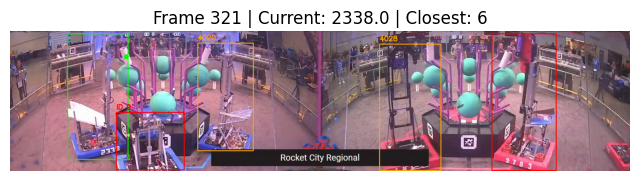

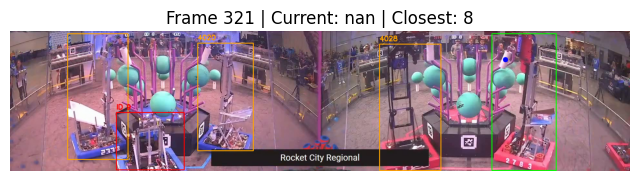


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


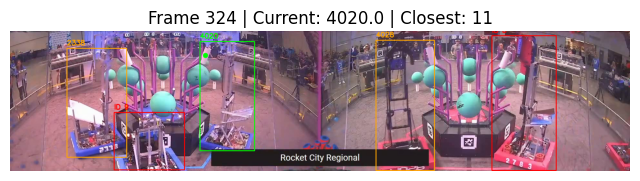

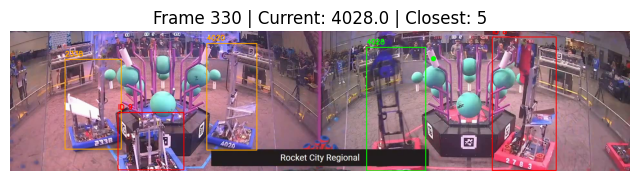

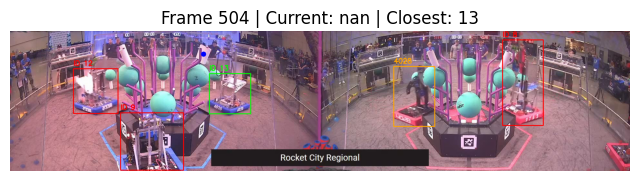


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


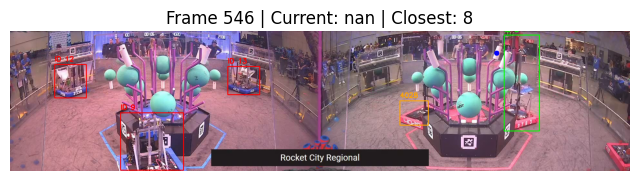


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


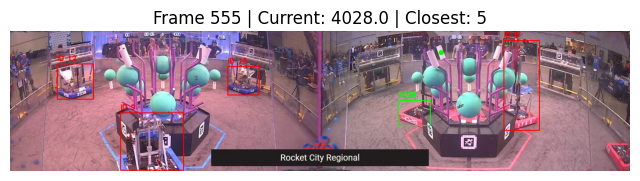

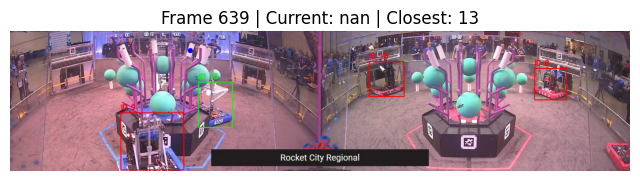


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


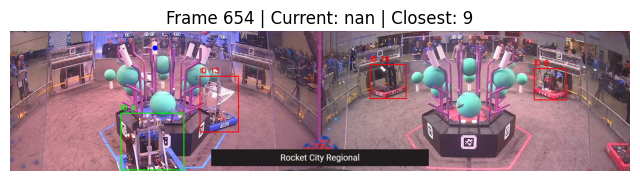


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


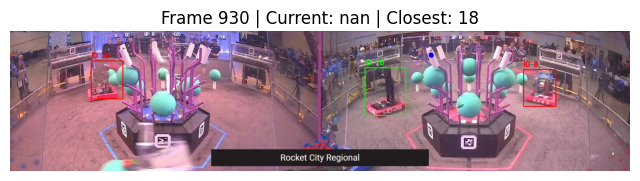


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


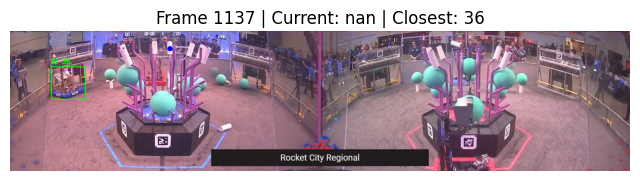


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


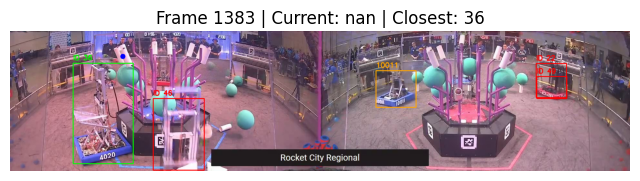


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


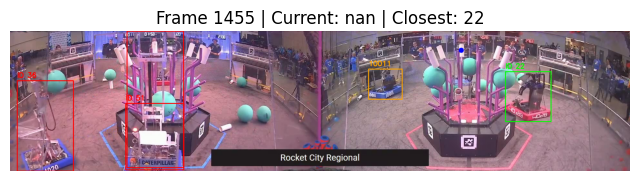


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


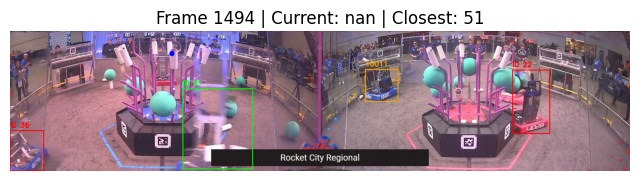


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


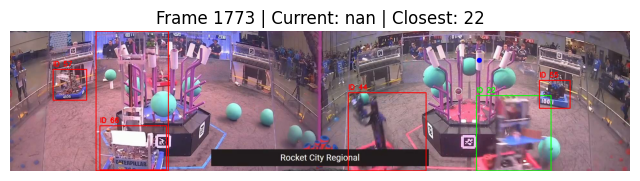


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


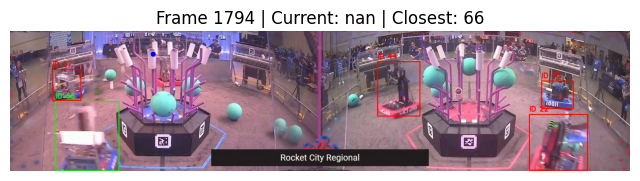


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


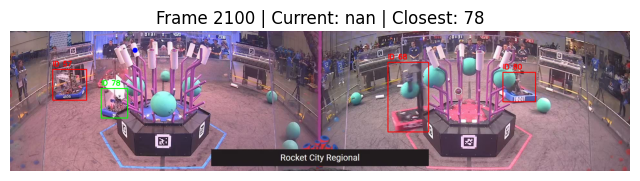


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


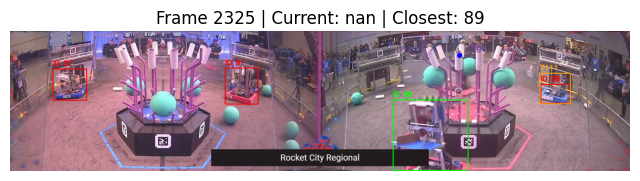


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


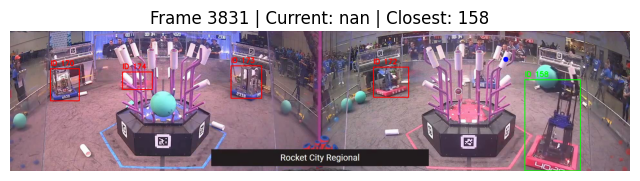


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


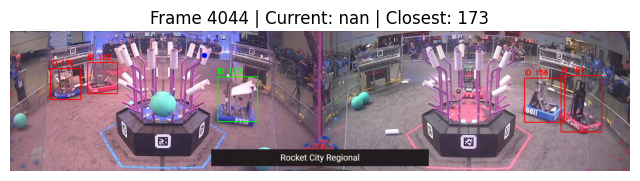


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


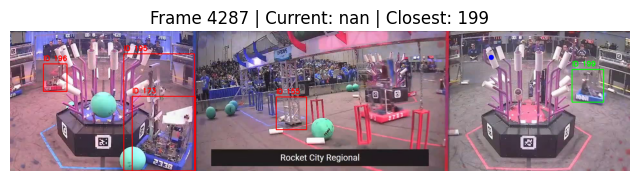


Select robot:
1: 10011
2: 4020
3: 2338
4: 2783
5: 4028
6: 7111
0: Unknown


In [24]:
user_labels = review_all_events(
    VIDEO_PATH,
    assigned_df,
    tracking_lookup,
    botsort_results["final_labels"],
    BLUE_IDS,
    RED_IDS
)

In [25]:
for entry in user_labels:
    idx = entry["index"]
    assigned_df.loc[idx, "robot_id"] = entry["robot_id"]

In [26]:
scoring_counts = (
    assigned_df
    .dropna(subset=["robot_id"])
    .groupby("robot_id")
    .size()
    .reset_index(name="coral_scored")
)

print(scoring_counts)

   robot_id  coral_scored
0    2338.0             6
1    2783.0             2
2    4020.0             4
3    4028.0             4
